### Install the required packages

In [39]:
%pip install -q -U langchain_openai langchain_core langgraph

### Install Langfuse package

In [40]:
%pip install -q langfuse

### Install SendGrid Python SDK for email API integration

In [41]:
!pip install sendgrid

### Set up Environment

In [42]:
import os

os.environ["SENDGRID_API_KEY"] = ""
# Set your OpenAI API key here
os.environ["OPENAI_API_KEY"] = ""  # Replace with your actual API key

# Get keys for your project from the project settings page: https://cloud.langfuse.com
os.environ["LANGFUSE_PUBLIC_KEY"] = ""
os.environ["LANGFUSE_SECRET_KEY"] = ""
#os.environ["LANGFUSE_HOST"] = "https://cloud.langfuse.com"  # 🇪🇺 EU region
os.environ["LANGFUSE_HOST"] = "https://us.cloud.langfuse.com" # 🇺🇸 US region

### Initialize Langfuse callback handler for tracing and observability

In [43]:
from langfuse.langchain import CallbackHandler

# Initialize Langfuse CallbackHandler for LangGraph/Langchain (tracing)
langfuse_handler = CallbackHandler()

### Define custom tools for image text extraction[extract_text] and mathematical division[divide]

In [44]:
import base64
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI

vision_llm = ChatOpenAI(model="gpt-4o")


def extract_text(img_path: str) -> str:
    """
    Extract text from an image file using a multimodal model.

    Args:
        img_path: A local image file path (strings).

    Returns:
        A single string containing the concatenated text extracted from each image.
    """
    all_text = ""
    try:

        # Read image and encode as base64
        with open(img_path, "rb") as image_file:
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        # Prepare the prompt including the base64 image data
        message = [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": (
                            "Extract all the text from this image. "
                            "Return only the extracted text, no explanations."
                        ),
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        },
                    },
                ]
            )
        ]

        # Call the vision-capable model
        response = vision_llm.invoke(message)

        # Append extracted text
        all_text += response.content + "\n\n"

        return all_text.strip()
    except Exception as e:
        # You can choose whether to raise or just return an empty string / error message
        error_msg = f"Error extracting text: {str(e)}"
        print(error_msg)
        return ""


llm = ChatOpenAI(model="gpt-4o")


def divide(a: int, b: int) -> float:
    """Divide a and b."""
    return a / b


### Create a SendGrid-powered function to send HTML emails via API client

In [45]:
from sendgrid import SendGridAPIClient
from sendgrid.helpers.mail import Mail

def send_html_email(html_body: str,
                    sender: str = "malahittrainer@gmail.com",
                    receiver: str = "malahittrainer@gmail.com",
                    subject: str = "Dinner shopping list") -> str:
    """
    Send an HTML e-mail via SendGrid.

    Args:
        html_body:  Valid HTML to be used as the message body.
        sender:     Verified 'from' address in your SendGrid account.
        receiver:   Destination address (must be verified in free tier).
        subject:    Subject line.

    Returns:
        Status string for the agent to read back.
    """
    message = Mail(
        from_email=sender,
        to_emails=receiver,
        subject=subject,
        html_content=html_body
    )
    try:
        sg = SendGridAPIClient(os.environ["SENDGRID_API_KEY"])
        resp = sg.send(message)
        return f"✉️ SendGrid response {resp.status_code}"
    except Exception as e:
        return f"❌ SendGrid error: {e}"


### Bind the LLM with custom tools for tool calling execution

In [46]:
tools = [divide, extract_text, send_html_email]

llm_with_tools = llm.bind_tools(
    tools,
    parallel_tool_calls=False,
    #force_tool=True
)

### Define the agent state schema for messages and input file handling

In [47]:
from typing import TypedDict, Annotated, Optional
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The input document
    input_file: Optional[str]  # Contains file path, type (PNG)
    messages: Annotated[list[AnyMessage], add_messages]

### Extend LangGraph assistant with image analysis, math, and email-sending tools via system prompt injection

In [48]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.utils.function_calling import convert_to_openai_tool


def assistant(state: AgentState):
    # System message
    textual_description_of_tool = """
extract_text(img_path: str) -> str:
    Extract text from an image file using a multimodal model.

    Args:
        img_path: A local image file path (strings).

    Returns:
        A single string containing the concatenated text extracted from each image.
divide(a: int, b: int) -> float:
    Divide a and b

    send_html_email(html_body: str,
                sender: str,
                receiver: str,
                subject: str) -> str:
    Send an HTML e-mail via SendGrid and return a status string.
"""
    image = state["input_file"]
    sys_msg = SystemMessage(content=f"You are an helpful agent that can analyse some images and run some computations with provided tools :\n{textual_description_of_tool} \n You have access to some otpional images. Currently the loaded images is : {image}")

    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])], "input_file": state["input_file"]}

### Build and compile a LangGraph ReAct agent with tool routing and visualization

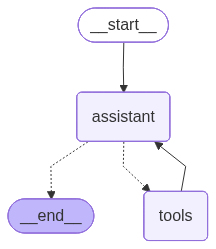

In [49]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# Graph
builder = StateGraph(AgentState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

### Invoke the LangGraph ReAct agent with a tool-enabled prompt and Langfuse tracing callback

In [50]:
messages = [HumanMessage(content="Divide 10000 by 5")]

messages = react_graph.invoke({"messages": messages, "input_file": None}, config={"callbacks": [langfuse_handler]})

### Pretty-print the full message trace from the LangGraph agent execution

In [51]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide 10000 by 5
================================== Ai Message ==================================
Tool Calls:
  divide (call_Xe0YehMZv0aBTb5cIAvAjPT7)
 Call ID: call_Xe0YehMZv0aBTb5cIAvAjPT7
  Args:
    a: 10000
    b: 5
================================= Tool Message =================================
Name: divide

2000.0
================================== Ai Message ==================================

10000 divided by 5 equals 2000.0.


### Run a multimodal LangGraph ReAct agent to extract shopping items from an image-based note

In [52]:
# Create initial messages
messages = [HumanMessage(content="According to the note provided by Mr. Wayne in the provided images, what's the list of items I should buy for the dinner menu?")]

# Invoke react_graph with Langfuse callback integrated
messages = react_graph.invoke(
    {
        "messages": messages,
        "input_file": "/content/Batman_training_and_meals.png"
    },
    config={"callbacks": [langfuse_handler]}
)

### Pretty-print the full message trace from the LangGraph agent execution

In [53]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

According to the note provided by Mr. Wayne in the provided images, what's the list of items I should buy for the dinner menu?
================================== Ai Message ==================================
Tool Calls:
  extract_text (call_mKVTOaLRKAuCHrCzSFLJrRd9)
 Call ID: call_mKVTOaLRKAuCHrCzSFLJrRd9
  Args:
    img_path: /content/Batman_training_and_meals.png
================================= Tool Message =================================
Name: extract_text

TRAINING SCHEDULE
For the week of 2/20-2/26

SUNDAY 2/20
MORNING
30 minute jog
30 minute meditation
EVENING
clean and jerk lifts—3 reps/8 sets. 262 lbs.
5 sets metabolic conditioning:
21 kettlebell swings
12 pull-ups
30 minutes flexibility
30 minutes sparring

MONDAY 2/21
MORNING
30 minute jog
30 minutes traditional kata (focus on Japanese forms)
EVENING
5 sets 20 foot rope climb
3 minutes gymnastics rings (work on muscle ups in
particular)
benc

### End-to-end multimodal ReAct workflow: extract image-based shopping list and compute derived numeric result via tools

In [54]:
# Create initial messages
messages = [HumanMessage(content="According to the note provided by Mr. Wayne in the provided images, what's the list of items I should buy for the dinner menu? Count the number of items and divide them by 50. Give resulting answer. Don't stop until you have integer answer")]

# Invoke react_graph with Langfuse callback integrated
messages = react_graph.invoke(
    {
        "messages": messages,
        "input_file": "Batman_training_and_meals.png"
    },
    config={"callbacks": [langfuse_handler]}
)

### Pretty-print the full message trace from the LangGraph agent execution

In [55]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

According to the note provided by Mr. Wayne in the provided images, what's the list of items I should buy for the dinner menu? Count the number of items and divide them by 50. Give resulting answer. Don't stop until you have integer answer
================================== Ai Message ==================================
Tool Calls:
  extract_text (call_61NwnlHcBlUbB0AwkjBZ8K4G)
 Call ID: call_61NwnlHcBlUbB0AwkjBZ8K4G
  Args:
    img_path: Batman_training_and_meals.png
================================= Tool Message =================================
Name: extract_text

```plaintext
TRAINING SCHEDULE
For the week of 2/20-2/26

SUNDAY 2/20
MORNING
30 minute jog
30 minute meditation

EVENING
clean and jerk lifts—3 reps/8 sets. 262 lbs.
5 sets metabolic conditioning:
20 push press
12 kettlebell swings
12 pull-ups
30 minutes flexibility
30 minutes sparring

MONDAY 2/21
MORNING
30 minute jog
30 minute traditional 

### Invoke the multimodal agent to extract a shopping list from an image and email the results

In [56]:
# Create initial messages
messages = [HumanMessage(content="According to the note provided by Mr. Wayne in the provided images, what's the list of items I should buy for the dinner menu? Then send an email to malahittrainer@gmail.com with the list of items")]

# Invoke react_graph with Langfuse callback integrated
messages = react_graph.invoke(
    {
        "messages": messages,
        "input_file": "Batman_training_and_meals.png"
    },
    config={"callbacks": [langfuse_handler]}
)

### Pretty-print the full message trace from the LangGraph agent execution

In [57]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

According to the note provided by Mr. Wayne in the provided images, what's the list of items I should buy for the dinner menu? Then send an email to malahittrainer@gmail.com with the list of items
================================== Ai Message ==================================
Tool Calls:
  extract_text (call_LHiNS18j5cnxoeLBkawSByIK)
 Call ID: call_LHiNS18j5cnxoeLBkawSByIK
  Args:
    img_path: Batman_training_and_meals.png
================================= Tool Message =================================
Name: extract_text

```
TRAINING SCHEDULE
For the week of 2/20-2/26

SUNDAY 2/20
MORNING
30 minute jog
30 minute meditation

EVENING
clean and jerk lifts—3 reps/8 sets. 262 lbs.
5 sets metabolic conditioning:
  21 kettlebell swings
  12 pull-ups
  10 minutes flexibility
30 minutes sparring

MONDAY 2/21
MORNING
30 minute jog
30 minutes traditional kata (focus on Japanese forms)

EVENING
5 sets 20 foot rope